### Importing libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

### Loading the cleaned dataset

In [2]:
fact_sales_df = pd.read_csv(r"C:\Data Analytics Projects\Cohort & Retention Analysis\Data\Cleaned\fact_sales.csv",
    parse_dates=['purchase_datetime']
)

In [3]:
fact_sales_df.head()

,order_id,order_status,purchase_datetime,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_key,city,state,item_id,product_id,item_price,freight_value,product_category,total_payment,payment_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,87285b34884572647811a353c7ac498a,29.99,8.72,Housewares,38.71,1.0,"credit_card, voucher"
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,Perfumery,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,159.90,19.22,Auto,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,Pet Shop,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,Stationery,28.62,1.0,credit_card


### Creating a new dataframe specifically for cohort analysis

In [4]:
cohort_df = fact_sales_df[
    [
        'customer_key',
        'order_id',
        'purchase_datetime',
        'total_payment'
    ]
].copy()

In [5]:
cohort_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110194 entries, 0 to 110193
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_key       110194 non-null  object        
 1   order_id           110194 non-null  object        
 2   purchase_datetime  110194 non-null  datetime64[ns]
 3   total_payment      110194 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.4+ MB


In [6]:
cohort_df.head()

,customer_key,order_id,purchase_datetime,total_payment
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,38.71
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,72.20
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,28.62


### Find each customer's first purchase (Acquisition Date)

In [7]:
cohort_df['purchase_month'] = (
    cohort_df['purchase_datetime']
    .dt.to_period('M')
)

In [8]:
cohort_df['cohort_month'] = (
    cohort_df
    .groupby('customer_key')['purchase_month']
    .transform('min')
)

In [9]:
cohort_df.head(10)

,customer_key,order_id,purchase_datetime,total_payment,purchase_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,38.71,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,72.20,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,28.62,2018-02,2018-02
5,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,175.26,2017-07,2017-07
6,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,75.16,2017-05,2017-05
7,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,35.95,2017-01,2017-01
8,299905e3934e9e181bfb2e164dd4b4f8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,169.76,2017-07,2017-07
9,f2a85dec752b8517b5e58a06ff3cd937,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,259.06,2017-05,2017-05


### Calculate Cohort Index (Months Since First Purchase)

In [10]:
# Purchase year and month
cohort_df['purchase_year'] = cohort_df['purchase_month'].dt.year
cohort_df['purchase_month_num'] = cohort_df['purchase_month'].dt.month

# Cohort year and month
cohort_df['cohort_year'] = cohort_df['cohort_month'].dt.year
cohort_df['cohort_month_num'] = cohort_df['cohort_month'].dt.month

# Months since first purchase
cohort_df['cohort_index'] = (
    (cohort_df['purchase_year'] - cohort_df['cohort_year']) * 12 +
    (cohort_df['purchase_month_num'] - cohort_df['cohort_month_num'])
)

In [11]:
cohort_df[['customer_key',
           'purchase_month',
           'cohort_month',
           'cohort_index']].head(10)

,customer_key,purchase_month,cohort_month,cohort_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,0
6,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,0
7,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,0
8,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,0
9,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05,0


### Building the Cohort Table

In [12]:
cohort_counts = (
    cohort_df
    .groupby(['cohort_month', 'cohort_index'])['customer_key']
    .nunique()
    .reset_index()
)

cohort_counts.head(15)

,cohort_month,cohort_index,customer_key
0,2016-10,0,262
1,2016-10,6,1
2,2016-10,9,1
3,2016-10,11,1
4,2016-10,13,1
5,2016-10,15,1
6,2016-10,17,1
7,2016-10,19,2
8,2016-10,20,2
9,2016-12,0,1


### Build the Cohort Retention Matrix

In [13]:
cohort_matrix = cohort_counts.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_key'
)

cohort_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN
2017-07,3752.0,20.0,13.0,9.0,11.0,8.0,12.0,4.0,7.0,10.0,8.0,11.0,5.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN


### Building Retention Matrix (%)

In [14]:
retention_matrix = cohort_matrix.divide(
    cohort_matrix[0],
    axis=0
)

retention_matrix = retention_matrix.round(4)

retention_matrix = (
    retention_matrix
    .fillna(0)
    .multiply(100)
    .round(2)
)

retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.38,0.00,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.00,0.38,0.76,0.76
2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,0.00,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,0.00
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,0.00,0.00
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,0.00,0.00


### Customer Retention Heatmap

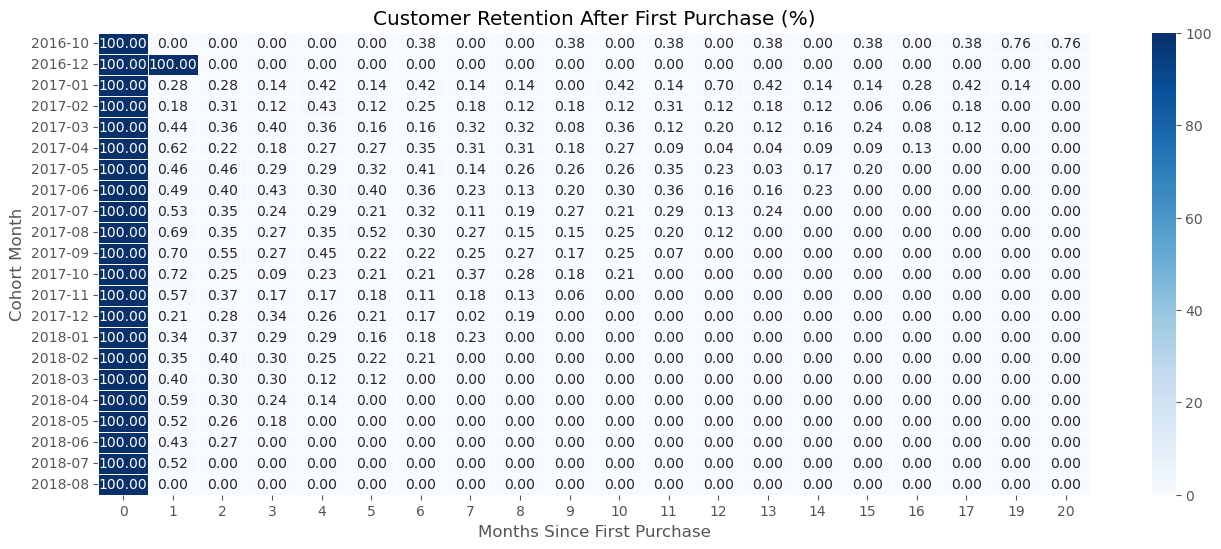

In [15]:
plt.figure(figsize=(16,6))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Customer Retention After First Purchase (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

##### Business Insight
Customer retention on the Olist marketplace is extremely low. Most customers make a single purchase and do not return, indicating that the business relies heavily on acquiring new customers rather than generating repeat purchases. This finding is consistent with the purchase frequency analysis, where 97% of customers placed only one order.

In [16]:
retention_matrix.to_csv("cohort_retention.csv")